# Assignment 1 — QANet

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

Run each section in order. Sections 0–1 are one-time setup steps; Sections 2–4 are the main training and evaluation pipeline.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# Adjust this path if your repo is stored elsewhere in Drive.
PROJECT_ROOT = "C:\\Users\\Administrator\\Documents\\coding\\comp5329\\ass1"
# PROJECT_ROOT = '/opt/jupyter/code/comp5329-ass01-main'

In [2]:
# Install Python dependencies (run once per session)
# !pip install -r {PROJECT_ROOT}/requirements.txt -q
# !python -m spacy download en

---
## Section 0 — Environment Setup

Mount Google Drive and install dependencies.

In [3]:
import sys, os

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: C:\Users\Administrator\Documents\coding\comp5329\ass1


---
## Section 1 — Download Data *(delete before submitting)*

Downloads the pre-built mini dataset (sampled SQuAD v1.1 train + full dev set,
with GloVe vectors filtered to the mini vocabulary) from GitHub Releases into `_data/`.

> **One-time step.** Once `_data/` exists on your Drive, delete this section before submission.

In [4]:
# from Tools.download import download_mini,download_squad,download_glove

# # download_mini(data_dir="_data")
# download_squad(squad_dir="_data/squad")

---
## Section 2 — Preprocess Data *(delete before submitting)*

Tokenises the SQuAD JSON files, builds word/char vocabularies from GloVe, and writes padded index tensors to `_data/`.

> **One-time step.** Once `_data/*.npz` exists on your Drive, delete this section before submission. Re-run only if you change `para_limit`, `ques_limit`, or other shape parameters.

In [5]:
from Tools.preproc import preprocess
print('-----------')
preprocess(
    train_file="_data/squad/train-mini.json",
    dev_file="_data/squad/dev-v1.1.json",
    glove_word_file="_data/glove/glove.mini.txt",
    target_dir="_data",
    para_limit=400,
    ques_limit=50,
)
print('-----------')

-----------
Generating train examples…


100%|██████████| 150/150 [00:02<00:00, 61.53it/s]


  30293 questions in total
Generating dev examples…


100%|██████████| 48/48 [00:01<00:00, 39.65it/s]


  10570 questions in total
Generating word embedding…


...

  53038 / 57695 tokens have a corresponding word embedding vector
Generating char embedding…
  748 tokens have a corresponding embedding vector
Processing train examples…


100%|██████████| 30293/30293 [00:03<00:00, 9761.91it/s] 


  Built 30169 / 30293 instances
Processing dev examples…


100%|██████████| 10570/10570 [00:01<00:00, 7908.92it/s]


  Built 10465 / 10570 instances
Saving word embedding…
Saving char embedding…
Saving train eval…
Saving dev eval…
Saving word dictionary…
Saving char dictionary…
Saving dev meta…

Preprocessing complete.
  Outputs → _data/
-----------


---
## Section 3 — Train

Trains QANet on SQuAD v1.1 and saves the best checkpoint to `_model/model.pt`.

100%|██████████| 1000/1000 [03:30<00:00,  4.75it/s]


STEP     1000  loss 112.645623



100%|██████████| 150/150 [00:08<00:00, 18.43it/s]


VALID(train) loss 4.571998  F1 7.809752  EM 0.083333



100%|██████████| 150/150 [00:08<00:00, 18.72it/s]


...

STEP    30000  loss 2.281790



100%|██████████| 150/150 [00:08<00:00, 18.10it/s]


VALID(train) loss 1.553427  F1 53.577160  EM 45.000000



100%|██████████| 150/150 [00:08<00:00, 17.94it/s]


TEST        loss 2.995843  F1 34.178100  EM 27.250000

Learning rate: [0.001]
Training finished.  Best F1: 34.1781  Best EM: 27.2500


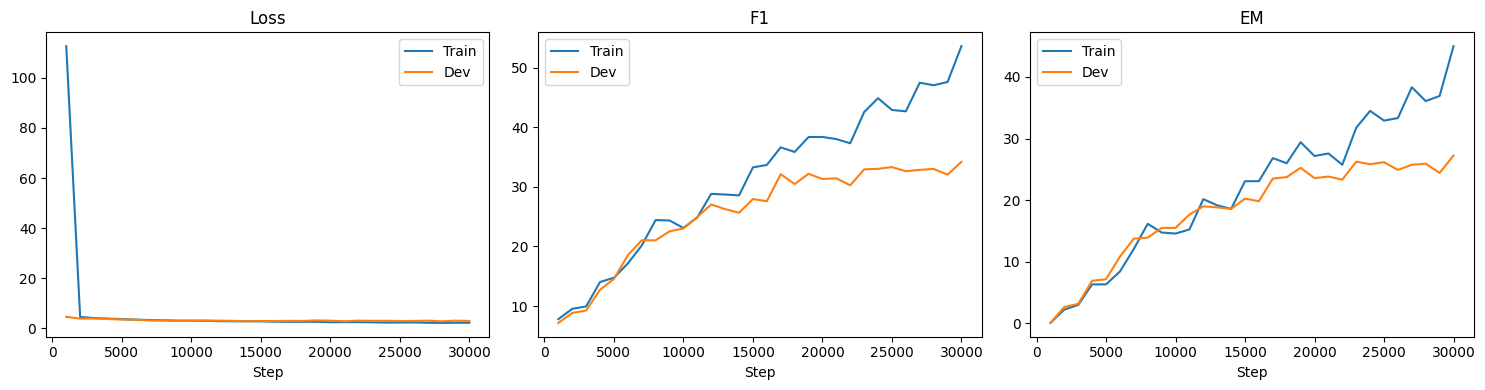

Best F1: 34.1781  |  Best EM: 27.2500


In [ ]:
from TrainTools.train import train

results = train(
    # ── data paths (must match preprocess outputs) ──────────────────────
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model",
    log_dir         = "_log",

    # ── training loop ────────────────────────────────────────────────────
    # num_steps  = 60000,
    num_steps = 30000,
    batch_size = 8,
    seed       = 42,

    # ── vanilla recipe: SGD, no scheduler, NLL loss ───────────────────────
    optimizer_name = "adam",#"sgd",
    scheduler_name = 'lambda',#"none",
    loss_name      = "qa_nll",
    
    checkpoint=1000,
    # momentum = 0.9,
    # dropout=0.2,
    # dropout_char=0.1,
    # init_name = 'xavier_normal', #'kaiming_normal'
    
)

print(f"Best F1: {results['best_f1']:.4f}  |  Best EM: {results['best_em']:.4f}")


print(f"Best F1: {results['best_f1']:.4f}  |  Best EM: {results['best_em']:.4f}")

---
## Section 4 — Evaluate

Loads the saved checkpoint and runs inference on the full dev set.

In [7]:
from EvaluateTools.evaluate import evaluate

metrics = evaluate(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    save_dir      = "_model",
    log_dir       = "_log",
    ckpt_name     = "model.pt",
)

print(f"F1: {metrics['f1']:.4f}  |  EM: {metrics['exact_match']:.4f}  |  Loss: {metrics['loss']:.6f}")

100%|██████████| 1309/1309 [01:11<00:00, 18.20it/s]


TEST  loss 3.085701  F1 32.399474  EM 22.990922
F1: 32.3995  |  EM: 22.9909  |  Loss: 3.085701
